In [ ]:
#%% Libraries
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier, BaggingRegressor, BaggingClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import ConfusionMatrixDisplay ,confusion_matrix, r2_score, make_scorer, mean_squared_error, mean_absolute_error, classification_report, silhouette_score, accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations_with_replacement
from scipy.stats import f_oneway, kruskal, ttest_ind, pearsonr, spearmanr, stats
import pickle
from sklearn.cluster import KMeans, DBSCAN
import warnings
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
warnings.filterwarnings("ignore")

class DataLoader:
    def __init__(self, filename, test_size=0.2, random_state=None):
        self.filename = filename
        self.test_size = test_size
        self.random_state = random_state
        self.data_train = None
        self.labels_train = None
        self.data_test = None
        self.labels_test = None
        self.df = None
        self._load_data()

    def _load_data(self):
        try:
            self.df = pd.read_csv(self.filename)
            X = self.df.drop(columns=['total_amount'])
            y = self.df['total_amount']
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=self.test_size, random_state=self.random_state
            )
            self.data_train = X_train
            self.labels_train = y_train
            self.data_test = X_test
            self.labels_test = y_test
            print("Data loaded successfully.")
        except FileNotFoundError:
            print("File not found. Please check the file path.")

    def get_full_data(self):
        return self.df


with open("data_loader.pkl", 'rb') as f:
    data_loader = pickle.load(f)


In [ ]:
class DataLoader:
    def __init__(self, filename, test_size=0.2, random_state=None, task='regression'):
        self.filename = filename
        self.test_size = test_size
        self.random_state = random_state
        self.task = task
        self.data_train = None
        self.labels_train = None
        self.data_test = None
        self.labels_test = None
        self.df = None
        self.scaler = None
        self._load_data()

    def _add_target(self):
        bins = [-np.inf, 10, 30, 60, np.inf]
        labels = [1, 2, 3, 4]
        self.df['fare_class'] = pd.cut(self.df['fare_amount'], bins=bins, labels=labels)

    def _preprocess_features(self, X):
        # Convert datetime
        X['tpep_pickup_datetime'] = pd.to_datetime(X['tpep_pickup_datetime'])
        X['tpep_dropoff_datetime'] = pd.to_datetime(X['tpep_dropoff_datetime'])
        X['pickup_hour'] = X['tpep_pickup_datetime'].dt.hour
        X['pickup_day'] = X['tpep_pickup_datetime'].dt.dayofweek
        X['trip_duration'] = (X['tpep_dropoff_datetime'] - X['tpep_pickup_datetime']).dt.total_seconds() / 60
        X = X.drop(columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])

        # Encode categorical
        X['store_and_fwd_flag'] = X['store_and_fwd_flag'].map({'Y': 1, 'N': 0})
        le = LabelEncoder()
        for col in ['PULocationID', 'DOLocationID']:
            X[col] = le.fit_transform(X[col])
        X = pd.get_dummies(X, columns=['RatecodeID', 'payment_type'])

        # Scale features
        numerical = ['passenger_count', 'trip_distance', 'pickup_hour', 'pickup_day', 'trip_duration']
        if self.scaler:
            X[numerical] = self.scaler.transform(X[numerical])
        else:
            self.scaler = StandardScaler().fit(X[numerical])
            X[numerical] = self.scaler.transform(X[numerical])
            # Ensure all columns are float64
        X = X.astype(np.float64)
        return X
        


    def _load_data(self):
        try:
            self.df = pd.read_csv(self.filename)
            if self.task == 'classification':
                self._add_target()

            # Drop columns based on task
            drop_cols = ['total_amount', 'extra', 'mta_tax', 'tip_amount', 
                          'tolls_amount', 'improvement_surcharge', 'congestion_surcharge']
            target = 'fare_amount' if self.task == 'regression' else 'fare_class'
            X = self.df.drop(columns=drop_cols + [target])
            y = self.df[target]

            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=self.test_size, random_state=self.random_state
            )

            # Preprocess
            self.data_train = self._preprocess_features(X_train)
            self.data_test = self._preprocess_features(X_test)
            self.labels_train = y_train.values
            self.labels_test = y_test.values

            print("Data loaded successfully.")
        except FileNotFoundError:
            print("File not found.")
class KNNRegressor:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = X_train.to_numpy().astype(np.float64)
        self.y_train = y_train.astype(np.float64)

    def _euclidean_distance(self, x):
        return np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

    def predict(self, X_test):
        X_test = X_test.to_numpy().astype(np.float64)        
        preds = []
        for x in X_test:
            dists = self._euclidean_distance(x)
            k_indices = np.argpartition(dists, self.k)[:self.k]
            preds.append(np.mean(self.y_train[k_indices]))
        return np.array(preds)
    
    def evaluate(self, X_test, y_test, plot=True):
        """Evaluate model performance with optional plots"""
        y_pred = self.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        print(f"Mean Absolute Error: ${mae:.2f}")
        print(f"R-squared Score: {r2:.3f}")
        
        if plot:
            plt.figure(figsize=(12, 5))
            
            # Actual vs Predicted plot
            plt.subplot(1, 2, 1)
            sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
            plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
            plt.xlabel('Actual Fare Amount ($)')
            plt.ylabel('Predicted Fare Amount ($)')
            plt.title('Actual vs Predicted Fares')
            
            # Error distribution plot
            plt.subplot(1, 2, 2)
            errors = y_test - y_pred
            sns.histplot(errors, kde=True, bins=30)
            plt.axvline(x=0, color='r', linestyle='--')
            plt.xlabel('Prediction Error ($)')
            plt.title('Error Distribution')
            
            plt.tight_layout()
            plt.show()
            
        return {'mae': mae, 'r2': r2}
    
class KNNClassifier:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = X_train.to_numpy().astype(np.float64)
        self.y_train = y_train

    def _euclidean_distance(self, x):
        return np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

    def predict(self, X_test):
        X_test = X_test.to_numpy().astype(np.float64)
        preds = []
        for x in X_test:
            dists = self._euclidean_distance(x)
            k_indices = np.argpartition(dists, self.k)[:self.k]
            k_labels = self.y_train[k_indices]
            preds.append(Counter(k_labels).most_common(1)[0][0])
        return np.array(preds)
    
    def evaluate(self, X_test, y_test, plot=True):
        """Evaluate model performance with optional plots"""
        y_pred = self.predict(X_test)
        accuracy = np.mean(y_pred == y_test)
        
        print(f"Accuracy: {accuracy*100:.1f}%")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=[
            "Class 1 (<$10)", "Class 2 ($10-$30)", 
            "Class 3 ($30-$60)", "Class 4 (>$60)"
        ]))
        
        if plot:
            plt.figure(figsize=(12, 5))
            
            # Confusion matrix
            plt.subplot(1, 2, 1)
            cm = confusion_matrix(y_test, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Class 1', 'Class 2', 'Class 3', 'Class 4'],
                        yticklabels=['Class 1', 'Class 2', 'Class 3', 'Class 4'])
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.title('Confusion Matrix')
            
            # Class distribution comparison
            plt.subplot(1, 2, 2)
            class_names = ['Class 1', 'Class 2', 'Class 3', 'Class 4']
            actual_counts = [sum(y_test == i) for i in range(1,5)]
            pred_counts = [sum(y_pred == i) for i in range(1,5)]
            
            x = np.arange(len(class_names))
            width = 0.35
            
            plt.bar(x - width/2, actual_counts, width, label='Actual')
            plt.bar(x + width/2, pred_counts, width, label='Predicted')
            
            plt.xlabel('Fare Classes')
            plt.ylabel('Count')
            plt.title('Actual vs Predicted Class Distribution')
            plt.xticks(x, class_names)
            plt.legend()
            
            plt.tight_layout()
            plt.show()
            
        return {'accuracy': accuracy}

print("\n=== Regression Task ===")
loader_reg = DataLoader("yellow_tripdata_2019-01\yellow_tripdata_2019-01.csv", task='regression', test_size=0.1)

# Train and predict
knn_reg = KNNRegressor(k=3)
knn_reg.fit(loader_reg.data_train, loader_reg.labels_train)
pred_reg = knn_reg.predict(loader_reg.data_test.iloc[:50])  # Predict on first 50 test samples

reg_results = knn_reg.evaluate(loader_reg.data_test.iloc[:50], loader_reg.labels_test[:50])

# Print predictions vs actual values
print("\nSample Predictions (Regression):")
for i in range(5):  # Show first 5 predictions
    print(f"Predicted: ${pred_reg[i]:.2f} | Actual: ${loader_reg.labels_test[i]:.2f}")

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(pred_reg - loader_reg.labels_test[:50]))
print(f"\nMean Absolute Error (MAE): ${mae:.2f}")

# --------------------------------------------------
# Classification Task
# --------------------------------------------------
print("\n=== Classification Task ===")
loader_clf = DataLoader("yellow_tripdata_2019-01\yellow_tripdata_2019-01.csv", task='classification', test_size=0.1)

# Train and predict
knn_clf = KNNClassifier(k=3)
knn_clf.fit(loader_clf.data_train, loader_clf.labels_train)
pred_clf = knn_clf.predict(loader_clf.data_test.iloc[:50])  # Predict on first 50 test samples

# Print predictions vs actual classes
print("\nSample Predictions (Classification):")
class_names = {
    1: "Short trip (<$10)",
    2: "Medium trip ($10-$30)",
    3: "Long trip ($30-$60)",
    4: "Premium fare (>$60)"
}
for i in range(5):  # Show first 5 predictions
    print(f"Predicted: {class_names[pred_clf[i]]} | Actual: {class_names[loader_clf.labels_test[i]]}")

clf_results = knn_clf.evaluate(loader_clf.data_test.iloc[:50], loader_clf.labels_test[:50])


# Calculate Accuracy
accuracy = np.mean(pred_clf == loader_clf.labels_test[:50])
print(f"\nAccuracy: {accuracy*100:.1f}%")



=== Regression Task ===
Data loaded successfully.

Sample Predictions (Regression):
Predicted: $20.83 | Actual: $5.00
Predicted: $24.33 | Actual: $6.50
Predicted: $10.50 | Actual: $12.50
Predicted: $7.33 | Actual: $4.50
Predicted: $8.50 | Actual: $14.50

Mean Absolute Error (MAE): $8.73

=== Classification Task ===
Data loaded successfully.

Sample Predictions (Classification):
Predicted: Medium trip ($10-$30) | Actual: Short trip (<$10)
Predicted: Short trip (<$10) | Actual: Short trip (<$10)
Predicted: Short trip (<$10) | Actual: Short trip (<$10)
Predicted: Short trip (<$10) | Actual: Short trip (<$10)
Predicted: Short trip (<$10) | Actual: Short trip (<$10)

Accuracy: 94.0%


In [ ]:
class Supervised_Learning():
    def __init__(self, data_loader):
        self.data_loader = data_loader
        self.X_train = self.data_loader.data_train.copy()
        self.y_train = self.data_loader.labels_train.copy()
        self.X_test = self.data_loader.data_test.copy()
        self.y_test = self.data_loader.labels_test.copy()
        self.feature_engineering()
        self.regression_model = None
        self.classification_model = None
        self._create_classification_targets()

    def _create_classification_targets(self):
        """Create binned fare classes for classification task"""
        bins = [-np.inf, 10, 30, 60, np.inf]
        labels = ['Class1', 'Class2', 'Class3', 'Class4']
        self.y_train_clf = pd.cut(self.y_train, bins=bins, labels=labels)
        self.y_test_clf = pd.cut(self.y_test, bins=bins, labels=labels)

    def feature_engineering(self):
        """Enhanced feature engineering with data leakage prevention"""
        # Process both training and test data
        for df in [self.X_train, self.X_test]:
            # Temporal features
            df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
            df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
            
            df['trip_duration'] = (df['tpep_dropoff_datetime'] - 
                                  df['tpep_pickup_datetime']).dt.total_seconds() / 60
            df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
            df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
            
            # Interaction features
            df['distance_per_passenger'] = df['trip_distance'] / (df['passenger_count'] + 1e-6)
            df['speed'] = df['trip_distance'] / (df['trip_duration'] / 60 + 1e-6)
            
            # Time-based features
            df['is_peak_hour'] = df['pickup_hour'].between(7, 9).astype(int)
            df['is_night'] = df['pickup_hour'].between(22, 4).astype(int)
            
            # Geographic features
            df['is_airport'] = ((df['PULocationID'].isin([1, 132]))) | ((df['DOLocationID'].isin([1, 132]))).astype(int)
            
            # Handle missing values properly
            numeric_cols = df.select_dtypes(include=np.number).columns
            cat_cols = df.select_dtypes(exclude=np.number).columns
            
            df[numeric_cols] = df[numeric_cols].fillna(0).replace([np.inf, -np.inf], 0)
            df[cat_cols] = df[cat_cols].fillna('Unknown')

    def prepare_data(self, task_type='regression'):
        """Prepare data for modeling"""
        features_to_drop = ['tpep_pickup_datetime', 'tpep_dropoff_datetime']
        X = self.X_train.drop(columns=features_to_drop, errors='ignore')
        X = pd.get_dummies(X)
        
        if task_type == 'regression':
            y = self.y_train
        else:
            y = self.y_train_clf
        
        return X, y

    def train_models(self):
        """Train both regression and classification models"""
        # Regression models
        reg_models = {
            "LinearRegression": LinearRegression(),
            "RandomForest": RandomForestRegressor(n_estimators=1, random_state=42),
            "GradientBoosting": GradientBoostingRegressor(n_estimators=1, random_state=42)
        }

        # Classification models
        clf_models = {
            "RandomForestClf": RandomForestClassifier(n_estimators=1, random_state=42),
            "GradientBoostingClf": GradientBoostingClassifier(n_estimators=1, random_state=42)
        }

        # Regression evaluation
        X_reg, y_reg = self.prepare_data('regression')
        reg_results = self._evaluate_models(reg_models, X_reg, y_reg, task_type='regression')

        # Classification evaluation
        X_clf, y_clf = self.prepare_data('classification')
        clf_results = self._evaluate_models(clf_models, X_clf, y_clf, task_type='classification')

        return {'regression': reg_results, 'classification': clf_results}

    def _evaluate_models(self, models, X, y, task_type='regression'):
        """Generic evaluation function"""
        results = {}
        scoring = 'neg_root_mean_squared_error' if task_type == 'regression' else 'accuracy'
        
        for name, model in models.items():
            scores = cross_val_score(model, X, y, scoring=scoring, cv=5)
            results[name] = {
                'mean_score': -np.mean(scores) if task_type == 'regression' else np.mean(scores),
                'std_score': np.std(scores)
            }
        return results

    def final_evaluation(self, model_type='regression', sample_size=20000):
        """Optimized final evaluation with test set sampling"""
        # Common setup
        if model_type == 'regression':
            model = GradientBoostingRegressor(n_estimators=1, random_state=42)
            X, y = self.prepare_data('regression')
            y_true = self.y_test
        else:
            model = GradientBoostingClassifier(n_estimators=1, random_state=42)
            X, y = self.prepare_data('classification')
            y_true = self.y_test_clf

        # Prepare full test set
        X_test_full = self.X_test.drop(columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime'], errors='ignore')
        X_test_full = pd.get_dummies(X_test_full).reindex(columns=X.columns, fill_value=0)
        X_test_full.fillna(0, inplace=True)

        # Strategic sampling
        if len(X_test_full) > sample_size:
            if model_type == 'classification':
                # Stratified sampling to preserve class distribution
                X_test, _, y_true, _ = train_test_split(
                    X_test_full, y_true, 
                    train_size=sample_size, 
                    stratify=y_true, 
                    random_state=42
                )
            else:
                # Random sampling with noise filtering
                idx = X_test_full.sample(sample_size, random_state=42).index
                X_test = X_test_full.loc[idx]
                y_true = y_true.loc[idx]
        else:
            X_test = X_test_full

        # Train on full data but evaluate on sample
        model.fit(X, y)
        preds = model.predict(X_test)
        
        # Generate evaluation plots
        plt.figure(figsize=(15, 5))
        if model_type == 'regression':
            # Actual vs Predicted values
            plt.subplot(1, 3, 1)
            plt.scatter(y_true, preds, alpha=0.3)
            plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
            plt.xlabel('Actual')
            plt.ylabel('Predicted')
            plt.title('Actual vs. Predicted')
            
            # Residuals plot
            residuals = y_true - preds
            plt.subplot(1, 3, 2)
            plt.scatter(preds, residuals, alpha=0.3)
            plt.axhline(0, color='r', linestyle='--')
            plt.xlabel('Predicted')
            plt.ylabel('Residuals')
            plt.title('Residuals vs. Predicted')
            
            # Residual distribution
            plt.subplot(1, 3, 3)
            sns.histplot(residuals, kde=True)
            plt.xlabel('Residuals')
            plt.title('Residual Distribution')
        else:
            # Confusion matrix
            plt.subplot(1, 2, 1)
            cm = confusion_matrix(y_true, preds, labels=model.classes_)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
            disp.plot(ax=plt.gca())
            plt.title('Confusion Matrix')
            
            # Feature importances
            if hasattr(model, 'feature_importances_'):
                plt.subplot(1, 2, 2)
                importances = model.feature_importances_
                top_indices = np.argsort(importances)[-10:]
                plt.barh(range(len(top_indices)), importances[top_indices], align='center')
                plt.yticks(range(len(top_indices)), [X.columns[i] for i in top_indices])
                plt.xlabel('Importance')
                plt.title('Top 10 Feature Importances')
        
        plt.tight_layout()
        plt.show()

        # Return metrics based on sampled test set
        if model_type == 'regression':
            return {
                'MAE': mean_absolute_error(y_true, preds),
                'RMSE': np.sqrt(mean_squared_error(y_true, preds))
            }
        else:
            return {
                'Accuracy': accuracy_score(y_true, preds),
                'F1-Score': f1_score(y_true, preds, average='weighted')
            }

supervised_learning = Supervised_Learning(data_loader)
results = supervised_learning.train_models()

print("Regression Results:")
print(pd.DataFrame(results['regression']).T.sort_values("mean_score"))

print("\nClassification Results:")
print(pd.DataFrame(results['classification']).T.sort_values("mean_score"))

print("\nFinal Regression Evaluation:")
print(supervised_learning.final_evaluation('regression',  sample_size=500))

print("\nFinal Classification Evaluation:")
print(supervised_learning.final_evaluation('classification',  sample_size=200))

Regression Results:
                  mean_score  std_score
LinearRegression    0.098545   0.002462
RandomForest        0.154675   0.002104
GradientBoosting    5.419825   0.010398

Classification Results:
                     mean_score  std_score
GradientBoostingClf    0.954029   0.000393
RandomForestClf        0.991031   0.000916

Final Regression Evaluation:
{'MAE': 6.901548794171855, 'RMSE': 13.515745137262487}

Final Classification Evaluation:
{'Accuracy': 0.9409607692704782, 'F1-Score': 0.9412336936161689}


In [ ]:
class DataLoader:
    def __init__(self, file_path, test_size=0.1, random_state=42):
        # Load and preprocess data
        df = pd.read_csv(file_path)
        
        # Basic preprocessing (adjust based on your actual data)
        df = df[['trip_distance', 'total_amount', 'passenger_count', 
                'PULocationID', 'DOLocationID']].dropna()
        df['fare_amount'] = df['total_amount']  # Assuming fare_amount is our target
        
        # Split features/target
        X = df.drop('fare_amount', axis=1)
        y = df['fare_amount']
        
        # Train-test split
        self.data_train, self.data_test, self.labels_train, self.labels_test = \
            train_test_split(X, y, test_size=test_size, random_state=random_state)
            
    def process_for_classification(self):
        """Convert regression labels to classification bins"""
        bins = [-np.inf, 10, 30, 60, np.inf]
        labels = [1, 2, 3, 4]
        self.labels_train = pd.cut(self.labels_train, bins=bins, labels=labels)
        self.labels_test = pd.cut(self.labels_test, bins=bins, labels=labels)

class BaggingRegressionModel:
    """Predicts continuous fare amounts"""
    def __init__(self, n_estimators=50, max_samples=0.8, max_depth=10, random_state=0):
        base = DecisionTreeRegressor(max_depth=max_depth, random_state=random_state)
        self.model = BaggingRegressor(
            estimator=base,
            n_estimators=n_estimators,
            max_samples=max_samples,
            random_state=random_state,
            n_jobs=-1
        )

    def fit(self, loader):
        X = loader.data_train.select_dtypes(include=[np.number]).fillna(0).to_numpy()
        y = loader.labels_train.to_numpy()
        self.model.fit(X, y)

    def predict(self, loader):
        X_test = loader.data_test.select_dtypes(include=[np.number]).fillna(0).to_numpy()
        return self.model.predict(X_test)

    def evaluate(self, loader):
        preds = self.predict(loader)
        y_true = loader.labels_test.to_numpy()
        return {
            "MAE": mean_absolute_error(y_true, preds),
            "RMSE": np.sqrt(mean_squared_error(y_true, preds))
        }

class BoostingRegressionModel:
    """Predicts continuous fare amounts"""
    def __init__(self, n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0):
        self.model = GradientBoostingRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            random_state=random_state
        )

    def fit(self, loader):
        X = loader.data_train.select_dtypes(include=[np.number]).fillna(0).to_numpy()
        y = loader.labels_train.to_numpy()
        self.model.fit(X, y)

    def predict(self, loader):
        X_test = loader.data_test.select_dtypes(include=[np.number]).fillna(0).to_numpy()
        return self.model.predict(X_test)

    def evaluate(self, loader):
        preds = self.predict(loader)
        y_true = loader.labels_test.to_numpy()
        return {
            "MAE": mean_absolute_error(y_true, preds),
            "RMSE": np.sqrt(mean_squared_error(y_true, preds))
        }

class BaggingClassificationModel:
    """Classifies fares into 4 categories"""
    def __init__(self, n_estimators=50, max_samples=0.8, max_depth=10, random_state=0):
        base = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
        self.model = BaggingClassifier(
            estimator=base,
            n_estimators=n_estimators,
            max_samples=max_samples,
            random_state=random_state,
            n_jobs=-1
        )

    def fit(self, loader):
        X = loader.data_train.select_dtypes(include=[np.number]).fillna(0).to_numpy()
        y = loader.labels_train.to_numpy()
        self.model.fit(X, y)

    def predict(self, loader):
        X_test = loader.data_test.select_dtypes(include=[np.number]).fillna(0).to_numpy()
        return self.model.predict(X_test)

    def evaluate(self, loader):
        preds = self.predict(loader)
        y_true = loader.labels_test.to_numpy()
        return {
            "Accuracy": accuracy_score(y_true, preds),
            "F1-Score": f1_score(y_true, preds, average='weighted')
        }

class BoostingClassificationModel:
    """Classifies fares into 4 categories"""
    def __init__(self, n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0):
        self.model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            random_state=random_state
        )

    def fit(self, loader):
        X = loader.data_train.select_dtypes(include=[np.number]).fillna(0).to_numpy()
        y = loader.labels_train.to_numpy()
        self.model.fit(X, y)

    def predict(self, loader):
        X_test = loader.data_test.select_dtypes(include=[np.number]).fillna(0).to_numpy()
        return self.model.predict(X_test)

    def evaluate(self, loader):
        preds = self.predict(loader)
        y_true = loader.labels_test.to_numpy()
        return {
            "Accuracy": accuracy_score(y_true, preds),
            "F1-Score": f1_score(y_true, preds, average='weighted')
        }

if __name__ == "__main__":
    # Load data once
    loader = DataLoader(r"C:/Users/Alibek/Desktop/4th semester/CienciaDeDados/DC_Project/yellow_tripdata_2019-01/yellow_tripdata_2019-01.csv")

    print("\n=== REGRESSION TASK ===")
    # Bagging
    bag_reg = BaggingRegressionModel(n_estimators=50)
    bag_reg.fit(loader)
    print("Bagging Regression:", bag_reg.evaluate(loader))
    
    # Boosting
    boost_reg = BoostingRegressionModel(n_estimators=50)
    boost_reg.fit(loader)
    print("Boosting Regression:", boost_reg.evaluate(loader))
    
    print("\n=== CLASSIFICATION TASK ===")
    # Convert labels to classes
    loader.process_for_classification()
    
    # Bagging
    bag_clf = BaggingClassificationModel(n_estimators=50)
    bag_clf.fit(loader)
    print("Bagging Classification:", bag_clf.evaluate(loader))
    
    # Boosting
    boost_clf = BoostingClassificationModel(n_estimators=50)
    boost_clf.fit(loader)
    print("Boosting Classification:", boost_clf.evaluate(loader))



=== REGRESSION TASK ===
Bagging Regression: {'MAE': 0.04931232901361666, 'RMSE': 0.8131113063459868}
Boosting Regression: {'MAE': 0.7444197591848237, 'RMSE': 3.1184615682675845}

=== CLASSIFICATION TASK ===
Bagging Classification: {'Accuracy': 1.0, 'F1-Score': 1.0}


In [15]:
class TaxiFarePredictor:
    def __init__(self, data_loader):
        self.data_loader = data_loader
        self.regression_model = None
        self.classification_model = None
        self.scaler = None
        self.class_bins = [-np.inf, 10, 30, 60, np.inf]
        self.class_labels = [0, 1, 2, 3]  # Corresponding to your 4 classes
        
    def preprocess_data(self):
        """Preprocess the data for both regression and classification tasks"""
        df = self.data_loader.df.copy()
        
        # Convert datetime to useful features
        df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
        df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
        
        # Extract time features
        df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
        df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek
        df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
        
        # Convert categorical variables
        df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
        
        # Select features
        features = ['passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 
                'DOLocationID', 'payment_type', 'pickup_hour', 'pickup_day', 
                'trip_duration', 'extra', 'mta_tax', 'tolls_amount', 
                'improvement_surcharge', 'congestion_surcharge']
        
        # Target variables
        fare_amount = df['fare_amount'].values
        total_amount = df['total_amount'].values
        
        # Create classification target - convert to numeric explicitly
        fare_class = pd.cut(df['fare_amount'], bins=self.class_bins, labels=self.class_labels)
        fare_class = fare_class.astype('int64')  # Convert from category to int
        
        # Verify
        print("Class distribution:")
        print(pd.Series(fare_class).value_counts())

        # Split data
        X_train, X_test, y_reg_train, y_reg_test = train_test_split(
            df[features], fare_amount, test_size=0.2, random_state=42)
        
        _, _, y_cls_train, y_cls_test = train_test_split(
            df[features], fare_class, test_size=0.2, random_state=42)
        
        # Scale features
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        return (X_train_scaled, X_test_scaled, 
                y_reg_train, y_reg_test,
                y_cls_train, y_cls_test)
    
    def build_regression_model(self, input_shape):
        """Build a neural network for fare amount prediction"""
        model = Sequential([
            Dense(128, activation='relu', input_shape=(input_shape,)),
            BatchNormalization(),
            Dropout(0.2),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(1)  # Linear activation for regression
        ])
        
        model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='mse',
                     metrics=['mae'])
        return model
    
    def build_classification_model(self, input_shape, num_classes=4):
        """Build a neural network for fare classification"""
        model = Sequential([
            Dense(128, activation='relu', input_shape=(input_shape,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dense(num_classes, activation='softmax')
        ])
        
        model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
        return model
    
    def train_models(self):
        """Train both regression and classification models"""
        (X_train, X_test, 
         y_reg_train, y_reg_test,
         y_cls_train, y_cls_test) = self.preprocess_data()
        
        # Regression model
        print("Training regression model...")
        self.regression_model = self.build_regression_model(X_train.shape[1])
        
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        
        history_reg = self.regression_model.fit(
            X_train, y_reg_train,
            validation_data=(X_test, y_reg_test),
            epochs=50,
            batch_size=1024,
            callbacks=[early_stop],
            verbose=1)
        
        # Classification model
        print("\nTraining classification model...")
        self.classification_model = self.build_classification_model(X_train.shape[1])
        
        history_cls = self.classification_model.fit(
            X_train, y_cls_train,
            validation_data=(X_test, y_cls_test),
            epochs=50,
            batch_size=1024,
            callbacks=[early_stop],
            verbose=1)
        
        return history_reg, history_cls
    
    def evaluate_models(self, X_test, y_reg_test, y_cls_test):
        """Evaluate both models on test data"""
        # Regression evaluation
        reg_pred = self.regression_model.predict(X_test)
        reg_mse = mean_squared_error(y_reg_test, reg_pred)
        reg_rmse = np.sqrt(reg_mse)
        print(f"\nRegression Results - RMSE: {reg_rmse:.2f}")
        
        # Classification evaluation
        cls_pred = np.argmax(self.classification_model.predict(X_test), axis=1)
        cls_acc = accuracy_score(y_cls_test, cls_pred)
        print(f"\nClassification Results - Accuracy: {cls_acc:.2f}")
        print("\nClassification Report:")
        print(classification_report(y_cls_test, cls_pred, 
                                  target_names=['< $10', '$10-$30', '$30-$60', '> $60']))
        
        return reg_rmse, cls_acc

# Create and train the predictor
predictor = TaxiFarePredictor(data_loader)

reg_history, cls_history = predictor.train_models()

# Get the preprocessed test data
(_, X_test, _, y_reg_test, _, y_cls_test) = predictor.preprocess_data()

# Evaluate the models
predictor.evaluate_models(X_test, y_reg_test, y_cls_test)

predictor.regression_model.save("taxi_fare_regression_model.h5")
predictor.classification_model.save("taxi_fare_classifier.h5")

Class distribution:
fare_amount
0    4659069
1    2507860
2     467306
3      33557
Name: count, dtype: int64
Training regression model...
Epoch 1/50
5991/5991 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 35372.3789 - mae: 7.3246 - val_loss: 1406.0613 - val_mae: 6.9692
Epoch 2/50
5991/5991 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - loss: 94881.0312 - mae: 7.1834 - val_loss: 1406.0571 - val_mae: 6.9840
Epoch 3/50
5991/5991 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - loss: 40540.0195 - mae: 7.1459 - val_loss: 1406.1675 - val_mae: 6.8602
Epoch 4/50
5991/5991 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - loss: 48806.3906 - mae: 7.1151 - val_loss: 1406.0667 - val_mae: 6.9544
Epoch 5/50
5991/5991 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - loss: 9740.5820 - mae: 7.0339 - val_loss: 1406.0557 - val_mae: 6.9991
Epoch 6/50
5991/5991 ━━━━━━━━━━━━━━━━━━━━ 195s 32ms/step - loss: 7252.6646 - mae: 7.0374 - val_loss: 1423.2601 - val_mae: 9.2710
Epoch 7/50
5991/5991 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step - loss: 60461.4883 - mae: 7.2191 - val

              precision    recall  f1-score   support

       < $10       0.61      1.00      0.76    931977
     $10-$30       0.00      0.00      0.00    501204
     $30-$60       0.00      0.00      0.00     93650
       > $60       0.00      0.00      0.00      6728

    accuracy                           0.61   1533559
   macro avg       0.15      0.25      0.19   1533559
weighted avg       0.37      0.61      0.46   1533559



K-Means with 2 clusters - Silhouette: 0.458
K-Means with 3 clusters - Silhouette: 0.429
K-Means with 4 clusters - Silhouette: 0.329
K-Means with 5 clusters - Silhouette: 0.226


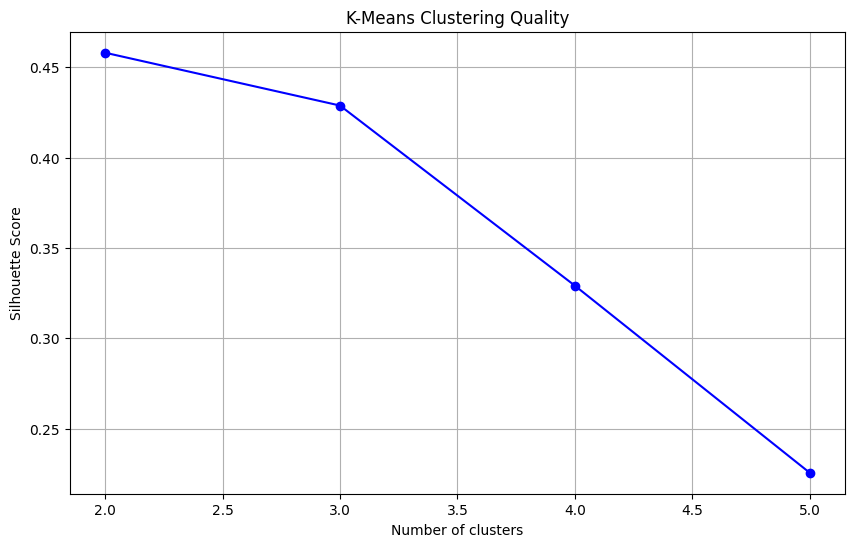

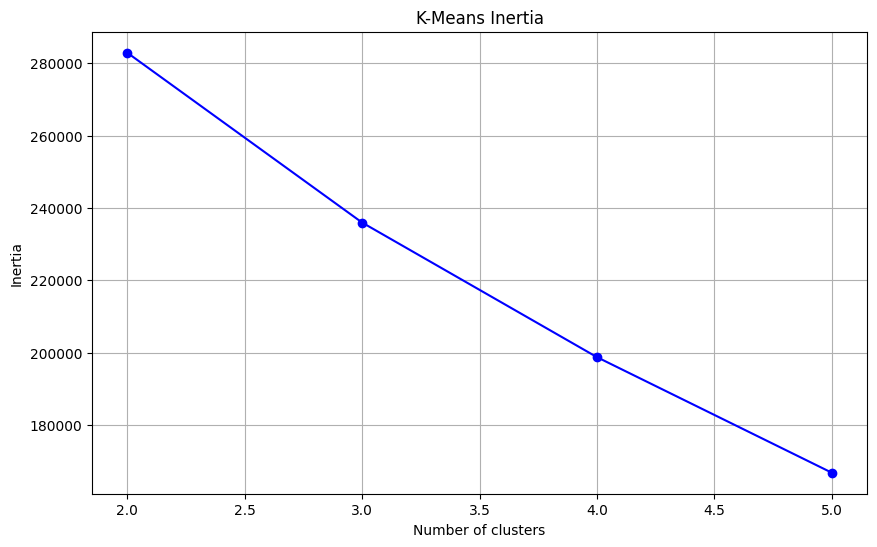

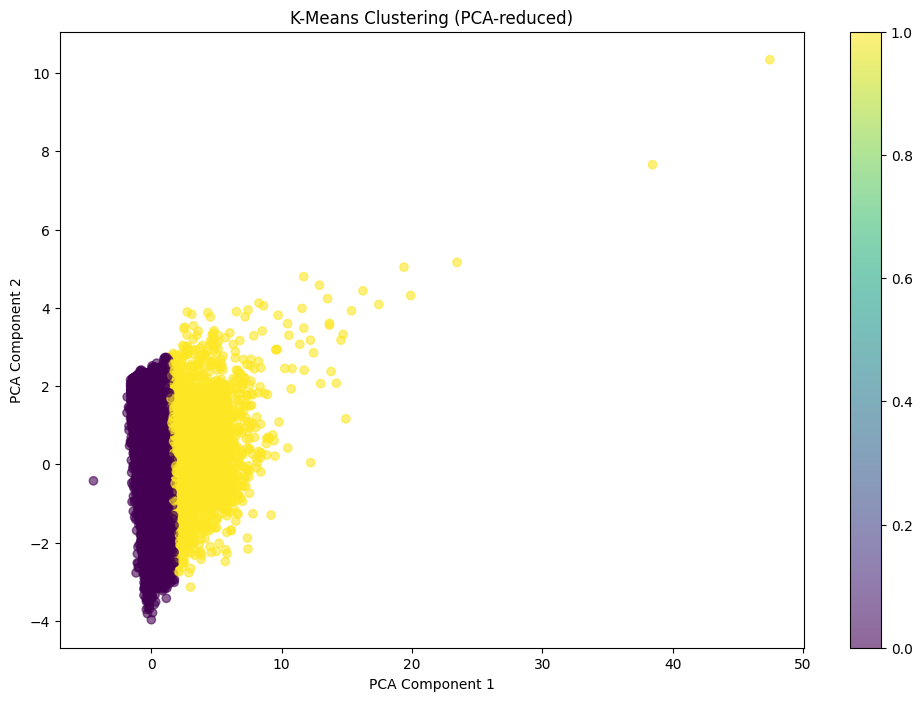


Cluster Characteristics:
         trip_distance  trip_duration  fare_amount  passenger_count  \
cluster                                                               
0             1.825632      10.859946     9.402188         1.558504   
1            12.372804      71.870575    40.036805         1.544218   

         hour_of_day  count  
cluster                      
0          13.812699  45296  
1          13.615434   4704  
DBSCAN (eps=0.5, min_samples=5) - Clusters: 121, Silhouette: -0.423, Noise: 3988
DBSCAN (eps=0.5, min_samples=10) - Clusters: 50, Silhouette: -0.365, Noise: 6224
DBSCAN (eps=0.5, min_samples=20) - Clusters: 35, Silhouette: -0.364, Noise: 9732
DBSCAN (eps=1.0, min_samples=5) - Clusters: 10, Silhouette: 0.292, Noise: 496
DBSCAN (eps=1.0, min_samples=10) - Clusters: 4, Silhouette: 0.313, Noise: 718
DBSCAN (eps=1.0, min_samples=20) - Clusters: 2, Silhouette: 0.311, Noise: 1080
DBSCAN (eps=1.5, min_samples=5) - Clusters: 3, Silhouette: 0.752, Noise: 167
DBSCAN (eps=1.

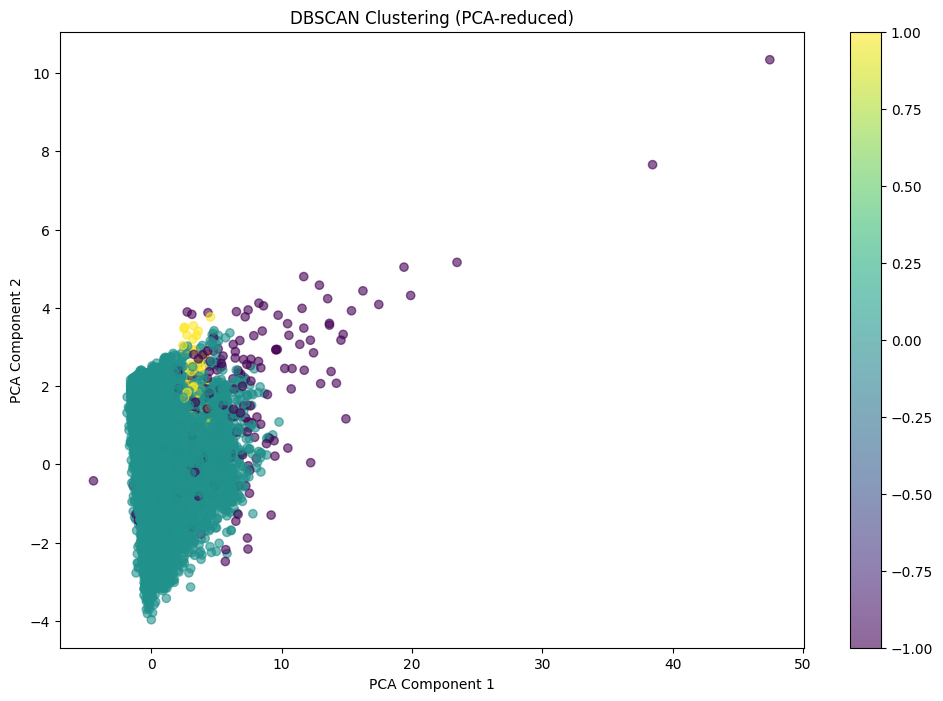


Cluster Characteristics:
         trip_distance  trip_duration  fare_amount  passenger_count  \
cluster                                                               
-1           14.608981     498.429207    66.915583         2.305825   
 0            2.770032      12.809251    12.059955         1.554474   
 1            2.067969    1411.107031    10.757812         1.234375   

         hour_of_day  count  
cluster                      
-1         12.276699    206  
 0         13.800261  49730  
 1         13.921875     64  


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration,hour_of_day,count
cluster,,,,,,,,,,,,,,,,,,
-1,1.878641,2.305825,14.608981,2.684466,155.660194,165.325243,1.315534,66.915583,0.228155,0.381068,7.559903,3.993981,0.288350,79.367039,0.0,498.429207,12.276699,206
0,1.637161,1.554474,2.770032,1.052946,165.252664,163.504766,1.289222,12.059955,0.328798,0.497582,1.802212,0.301996,0.299499,15.295359,0.0,12.809251,13.800261,49730
1,2.000000,1.234375,2.067969,1.000000,171.953125,175.375000,1.312500,10.757812,0.375000,0.500000,1.076719,0.000000,0.300000,13.009531,0.0,1411.107031,13.921875,64


In [16]:
class Clusterer:
    def __init__(self, data_loader, sample_size=50000, random_state=42):
        self.data_loader = data_loader
        self.sample_size = sample_size
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.df = None
        self.features = None
        self.scaled_features = None

    def preprocess_data(self):
        """Prepare data for clustering"""
        df = self.data_loader.get_full_data().copy()
        
        # Feature engineering
        df['trip_duration'] = (pd.to_datetime(df['tpep_dropoff_datetime']) - 
                              pd.to_datetime(df['tpep_pickup_datetime'])).dt.total_seconds() / 60
        df['hour_of_day'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
        df['is_weekend'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.weekday >= 5
        
        # Select relevant features for clustering
        features = [
            'trip_distance', 
            'trip_duration',
            'fare_amount',
            'passenger_count',
            'PULocationID',
            'DOLocationID',
            'hour_of_day'
        ]
        
        # Sample data
        self.df = df.sample(min(self.sample_size, len(df)), random_state=self.random_state)
        self.features = self.df[features]
        
        # Scale features
        self.scaled_features = self.scaler.fit_transform(self.features)
        return self.scaled_features

    def apply_kmeans(self, n_clusters_range=range(2, 8)):
        """Apply K-Means with varying cluster numbers"""
        results = {}
        silhouette_scores = []
        
        for n in n_clusters_range:
            kmeans = KMeans(n_clusters=n, random_state=self.random_state, n_init=10)
            cluster_labels = kmeans.fit_predict(self.scaled_features)
            
            silhouette = silhouette_score(self.scaled_features, cluster_labels)
            silhouette_scores.append(silhouette)
            
            results[n] = {
                'model': kmeans,
                'labels': cluster_labels,
                'silhouette': silhouette,
                'inertia': kmeans.inertia_
            }
            
            print(f"K-Means with {n} clusters - Silhouette: {silhouette:.3f}")
        
        # Plot results
        self._plot_cluster_metrics(
            n_clusters_range, 
            [results[n]['silhouette'] for n in n_clusters_range],
            'Silhouette Score',
            'K-Means Clustering Quality'
        )
        
        self._plot_cluster_metrics(
            n_clusters_range, 
            [results[n]['inertia'] for n in n_clusters_range],
            'Inertia',
            'K-Means Inertia'
        )
        
        return results

    def apply_dbscan(self, eps_range=[0.5, 1.0, 1.5], min_samples_range=[5, 10, 20]):
        """Apply DBSCAN with different parameters"""
        results = {}
        
        for eps in eps_range:
            for min_samples in min_samples_range:
                dbscan = DBSCAN(eps=eps, min_samples=min_samples)
                cluster_labels = dbscan.fit_predict(self.scaled_features)
                
                n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
                
                if n_clusters > 1:
                    silhouette = silhouette_score(self.scaled_features, cluster_labels)
                else:
                    silhouette = -1
                
                results[(eps, min_samples)] = {
                    'model': dbscan,
                    'labels': cluster_labels,
                    'silhouette': silhouette,
                    'n_clusters': n_clusters,
                    'noise_points': sum(cluster_labels == -1)
                }
                
                print(f"DBSCAN (eps={eps}, min_samples={min_samples}) - "
                      f"Clusters: {n_clusters}, Silhouette: {silhouette:.3f}, "
                      f"Noise: {results[(eps, min_samples)]['noise_points']}")
        
        return results

    def _plot_cluster_metrics(self, x_values, y_values, y_label, title):
        """Helper function to plot cluster metrics"""
        plt.figure(figsize=(10, 6))
        plt.plot(x_values, y_values, 'bo-')
        plt.xlabel('Number of clusters')
        plt.ylabel(y_label)
        plt.title(title)
        plt.grid(True)
        plt.show()

    def visualize_clusters(self, cluster_labels, algorithm_name):
        """Visualize clusters using PCA"""
        pca = PCA(n_components=2)
        reduced_data = pca.fit_transform(self.scaled_features)
        
        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], 
                            c=cluster_labels, cmap='viridis', alpha=0.6)
        plt.colorbar(scatter)
        plt.title(f'{algorithm_name} Clustering (PCA-reduced)')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.show()
        
        return cluster_labels

    def analyze_clusters(self, cluster_labels):
        """Analyze cluster characteristics"""
        temp_df = self.df.copy()
        temp_df['cluster'] = cluster_labels
        
        numeric_df = temp_df.select_dtypes(include=[np.number])
        cluster_stats = numeric_df.groupby('cluster').mean()
        cluster_counts = numeric_df['cluster'].value_counts().rename('count')
        
        result_df = cluster_stats.join(cluster_counts)
        
        print("\nCluster Characteristics:")
        print(result_df[['trip_distance', 'trip_duration', 'fare_amount', 
                       'passenger_count', 'hour_of_day', 'count']])
        
        return result_df

# Initialize components
clusterer = Clusterer(data_loader)
clusterer.preprocess_data()

# K-Means analysis
kmeans_results = clusterer.apply_kmeans(n_clusters_range=range(2, 6))
best_k = max(kmeans_results, key=lambda k: kmeans_results[k]['silhouette'])
labels = kmeans_results[best_k]['labels']

# Visualize and analyze
clusterer.visualize_clusters(labels, "K-Means")
cluster_stats = clusterer.analyze_clusters(labels)

# DBSCAN analysis (similar pattern)
dbscan_results = clusterer.apply_dbscan()
best_params = max(dbscan_results, key=lambda k: dbscan_results[k]['silhouette'])
labels_dbscan = dbscan_results[best_params]['labels']

clusterer.visualize_clusters(labels_dbscan, "DBSCAN")
clusterer.analyze_clusters(labels_dbscan)